## K-means

K-means 聚类是一种常用的无监督机器学习算法，用于将相似的数据点分组成 k 个簇。其目标是：将给定数据集划分为 k 个（预先定义好的）簇。

k-means 算法的工作方式是，先随机初始化 k 个簇中心，每个簇对应一个中心。然后，根据数据点与各簇中心之间的距离，将数据集中的每个数据点分配到最近的簇中心。通常使用的距离度量是欧几里得距离，但也可以使用其他距离度量，例如曼哈顿距离或余弦相似度。

当所有数据点都被分配到某个簇之后，算法会通过计算每个簇中所有数据点的平均值来得到该簇新的均值。这个新的均值会成为新的簇中心。随后，算法重复执行“分配”和“计算均值”这两个步骤，直到簇分配结果不再变化，或者达到最大迭代次数为止。

k-means 算法的最终输出是一组 k 个簇，其中每个簇都包含基于所用距离度量彼此最相似的数据点。该算法常用于图像分割、市场细分和客户画像等多个领域。


```
初始化：
- K：簇的数量
- Data：输入数据集
- 随机选择 K 个初始质心

重复：
- 将每个数据点分配给最近的质心（基于欧几里得距离）
- 计算每个簇的均值，并据此更新其质心
- 检查质心是否已经收敛（即不再变化）

直到：
- 质心已经收敛
- 达到最大迭代次数

输出：
- 最终的 K 个簇及其对应的质心
```


## 代码
下面给出一个使用 Python 从零实现的 k-means 聚类算法：

In [1]:
import numpy as np

class KMeans:
    def __init__(self, k, max_iterations=100):
        self.k = k
        self.max_iterations = max_iterations
        
    def fit(self, X):
        # Initialize centroids randomly
        self.centroids = X[np.random.choice(range(len(X)), self.k, replace=False)]
        
        for i in range(self.max_iterations):
            # Assign each data point to the nearest centroid
            cluster_assignments = []
            for j in range(len(X)):
                distances = np.linalg.norm(X[j] - self.centroids, axis=1)
                cluster_assignments.append(np.argmin(distances))
            
            # Update centroids
            for k in range(self.k):
                cluster_data_points = X[np.where(np.array(cluster_assignments) == k)]
                if len(cluster_data_points) > 0:
                    self.centroids[k] = np.mean(cluster_data_points, axis=0)
            
            # Check for convergence
            if i > 0 and np.array_equal(self.centroids, previous_centroids):
                break
            
            # Update previous centroids
            previous_centroids = np.copy(self.centroids)
        
        # Store the final cluster assignments
        self.cluster_assignments = cluster_assignments
    
    def predict(self, X):
        # Assign each data point to the nearest centroid
        cluster_assignments = []
        for j in range(len(X)):
            distances = np.linalg.norm(X[j] - self.centroids, axis=1)
            cluster_assignments.append(np.argmin(distances))
        
        return cluster_assignments

`KMeans` 类包含一个 `__init__` 方法，用于接收簇的数量（`k`）以及运行的最大迭代次数（`max_iterations`）。`fit` 方法接收输入数据集（`X`）并执行 k-means 聚类算法。`predict` 方法接收一个新的数据集（`X`），并基于训练过程中学习得到的质心，返回每个数据点对应的簇分配结果。

需要注意的是，这个实现假设输入数据集 `X` 是一个 NumPy 数组，其中每一行表示一个数据点，每一列表示一个特征。该算法还使用欧几里得距离来计算数据点与质心之间的距离。


### 测试

In [2]:

x1 = np.random.randn(5,2) + 5
x2 = np.random.randn(5,2) - 5
X = np.concatenate([x1,x2], axis=0)

# Initialize the KMeans object with k=3
kmeans = KMeans(k=2)

# Fit the k-means model to the dataset
kmeans.fit(X)

# Get the cluster assignments for the input dataset
cluster_assignments = kmeans.predict(X)

# Print the cluster assignments
print(cluster_assignments)

# Print the learned centroids
print(kmeans.centroids)

[1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
[[-5.53443211 -5.13920695]
 [ 4.46522152  5.04931144]]


### 可视化

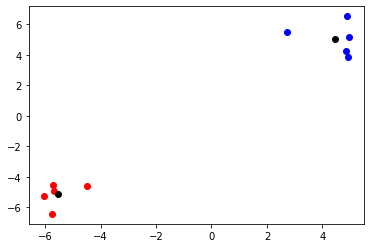

In [4]:
from matplotlib import pyplot as plt
# Plot the data points with different colors based on their cluster assignments
colors = ['r', 'b']
for i in range(kmeans.k):
    plt.scatter(X[np.where(np.array(cluster_assignments) == i)][:,0], 
                X[np.where(np.array(cluster_assignments) == i)][:,1], 
                color=colors[i])

# Plot the centroids as black circles
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], color='black', marker='o')

# Show the plot
plt.show()

### 优化
下面是一些优化 k-means 聚类算法的方法：

质心随机初始化：不要使用前 k 个数据点来初始化质心，而是采用随机初始化，以提升算法的收敛效果。具体做法是从输入数据集中随机选取 k 个数据点作为初始质心。

提前停止：如果经过若干次迭代后，簇分配结果和质心都不再变化，就可以提前停止 k-means 算法，从而避免不必要的计算。

向量化：可以使用 numpy 数组和向量化操作来加速计算。这样可以避免使用循环，并提升代码效率。

下面给出一个实现了上述优化的 k-means 聚类算法版本：

In [5]:
import numpy as np

class KMeans:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
    
    def fit(self, X):
        # Initialize centroids randomly
        self.centroids = X[np.random.choice(X.shape[0], self.k, replace=False)]
        
        # Iterate until convergence or maximum number of iterations is reached
        for i in range(self.max_iters):
            # Assign each data point to the closest centroid
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            cluster_assignments = np.argmin(distances, axis=1)
            
            # Update the centroids based on the new cluster assignments
            new_centroids = np.array([np.mean(X[np.where(cluster_assignments == j)], axis=0) 
                                      for j in range(self.k)])
            
            # Check for convergence
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
                
            self.centroids = new_centroids
    
    def predict(self, X):
        # Assign each data point to the closest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        cluster_assignments = np.argmin(distances, axis=1)
        
        return cluster_assignments


这个优化版本会随机初始化质心，使用向量化操作来计算距离并更新质心，同时在每次迭代后检查是否收敛；如果已经收敛，就停止算法。

后续问题：

* 计算复杂度：O(it * knd)
* 优化空间：使用索引而不是拷贝
* 优化时间：
  * 降维
  * 子采样（缺点？）
* mini-batch
* k-median https://mmuratarat.github.io/2019-07-23/kmeans_from_scratch